# **Modelo de IA para o reconhecimento de veículos🚗✈️⛵🚚 - Tensorflow**
**Pipeline de um Projeto de IA:**
Dados → Pré-processamento → Modelo → Treinamento → Validação → Teste → Inferência

Este projeto corresponde a um modelo de reconhecimento de imagens utilizando Tensorflow e treinado com um dataset disponibilizado pela página Keras. Possui como objetivo identificar veículos em diferentes contextos.


Dataset: `tf.keras.datasets.cifar10`, filtrado para as classes veiculares (60.000 imagens 32x32 originais → um subconjunto delas depois do filtro).

Filtramos dentre as 10 classes presentes nesse dataset apenas as 4 que possuem interesse na aplicação desenvolvida.


## **1. Bibliotecas + Dados**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2

In [2]:
# Carregar o CIFAR-10 completo (download automático e cacheado pelo Keras)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Treino (completo):", x_train.shape)
print("Teste  (completo):", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1744s 10us/step
Treino (completo): (50000, 32, 32, 3)
Teste  (completo): (10000, 32, 32, 3)


### 1.1 Filtrando só as classes de interesse

O CIFAR-10 tem 10 classes, mas só 4 delas fazem sentido pro tema "aviões e veículos": `airplane`, `automobile`, `ship` e `truck`. As outras 6 (`bird`, `cat`, `deer`, `dog`, `frog`, `horse`) são descartadas.

Filtrar deixa o problema mais fácil e o modelo mais preciso pro nosso objetivo específico — com menos classes concorrendo, a rede tende a confundir menos e a atingir uma acurácia mais alta nas classes que realmente importam.

In [3]:
# Classes originais do CIFAR-10 (para referência) e as que vamos manter
CLASSES_ORIGINAIS = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']

CLASSES_ALVO = {0: 'airplane', 1: 'automobile', 8: 'ship', 9: 'truck'}


def filtrar_classes(x, y, mapa_classes):
    """Mantém só as amostras cujas classes estão em mapa_classes e remapeia os rótulos para 0..N-1."""
    indices = np.isin(y.flatten(), list(mapa_classes.keys()))
    x_filtrado = x[indices]
    y_filtrado = y[indices]

    classes_originais_ordenadas = sorted(mapa_classes.keys())
    remapa = {classe_original: i for i, classe_original in enumerate(classes_originais_ordenadas)}
    y_remapeado = np.vectorize(remapa.get)(y_filtrado.flatten()).reshape(-1, 1)

    return x_filtrado, y_remapeado


x_train, y_train = filtrar_classes(x_train, y_train, CLASSES_ALVO)
x_test, y_test = filtrar_classes(x_test, y_test, CLASSES_ALVO)

class_names = [CLASSES_ALVO[c] for c in sorted(CLASSES_ALVO.keys())]
num_classes = len(class_names)

print("Classes usadas:", class_names)
print("Treino (filtrado):", x_train.shape)
print("Teste  (filtrado):", x_test.shape)

Classes usadas: ['airplane', 'automobile', 'ship', 'truck']
Treino (filtrado): (20000, 32, 32, 3)
Teste  (filtrado): (4000, 32, 32, 3)


## **2. Visualização dos dados**

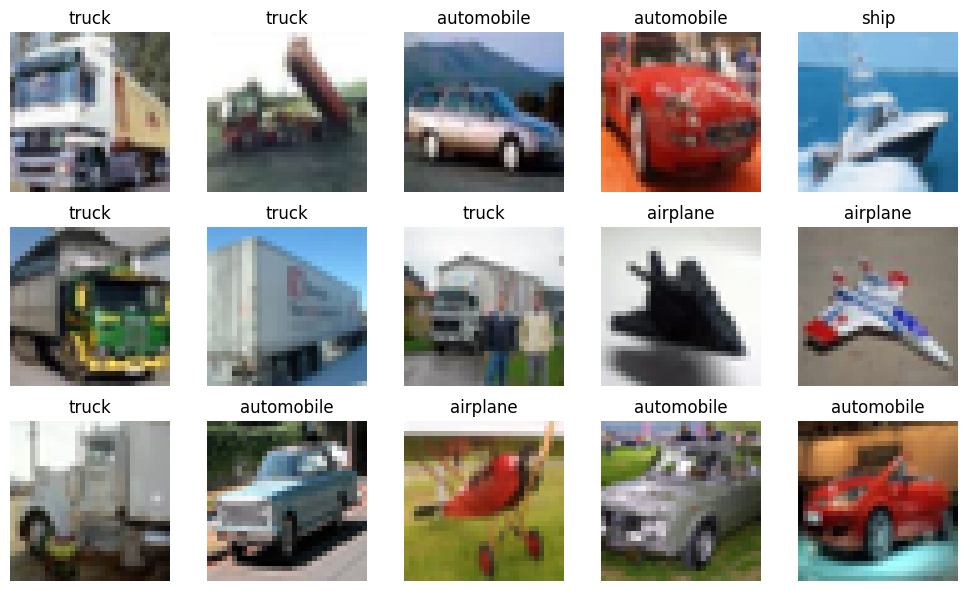

In [4]:
plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## **3. Pré-processamento**

In [5]:
print("Antes:", x_train.min(), "a", x_train.max())

# Normalização: 0–255 → 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Depois:", x_train.min(), "a", x_train.max())

Antes: 0 a 255
Depois: 0.0 a 1.0


## **4. Construção do Modelo🔧**

In [6]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,172 (653.02 KB)

 Trainable params: 167,172 (653.02 KB)

 Non-trainable params: 0 (0.00 B)

## **5. Treinamento + Validação📈**

46 épocas, com 20% do treino separado para validação.

O número de épocas foi escolhido após alguns testes, notando qual seria o melhor valor para maximizarmos o resultado.

In [7]:
history = model.fit(
    x_train,
    y_train,
    epochs=46,
    validation_split=0.2
)

Epoch 1/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5845 - loss: 0.9647 - val_accuracy: 0.6760 - val_loss: 0.8346
Epoch 2/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7170 - loss: 0.7133 - val_accuracy: 0.7545 - val_loss: 0.6309
Epoch 3/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7757 - loss: 0.5857 - val_accuracy: 0.7847 - val_loss: 0.5576
Epoch 4/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8088 - loss: 0.5047 - val_accuracy: 0.7943 - val_loss: 0.5313
Epoch 5/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8413 - loss: 0.4283 - val_accuracy: 0.7855 - val_loss: 0.5665
Epoch 6/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8615 - loss: 0.3744 - val_accuracy: 0.8060 - val_loss: 0.5210
Epoch 7/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8814 - loss: 0.3224 - val_accuracy: 0.8360 - val_loss: 0.4669
Epoch 8/46
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8967 - loss: 0.2800 - val_accuracy: 0.

## **6. Avaliação do Modelo**

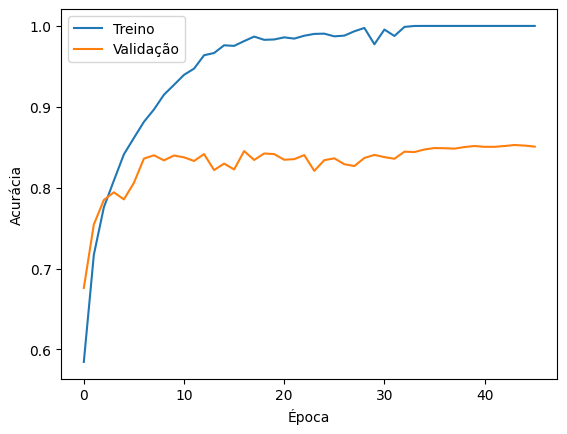

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8435 - loss: 1.4440

Acurácia no teste: 84.35%


In [8]:
# Curvas de aprendizado
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

# Avaliação final
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"\nAcurácia no teste: {test_accuracy:.2%}")

### **6.1 Matriz de confusão**

Com só 4 classes, a matriz fica bem enxuta e fácil de ler.

- **Diagonal principal:** classificações corretas.
- **Fora da diagonal:** classes que o modelo confundiu — de olho principalmente em `automobile`/`truck`, que costumam ser o par mais confundido nesse subconjunto.

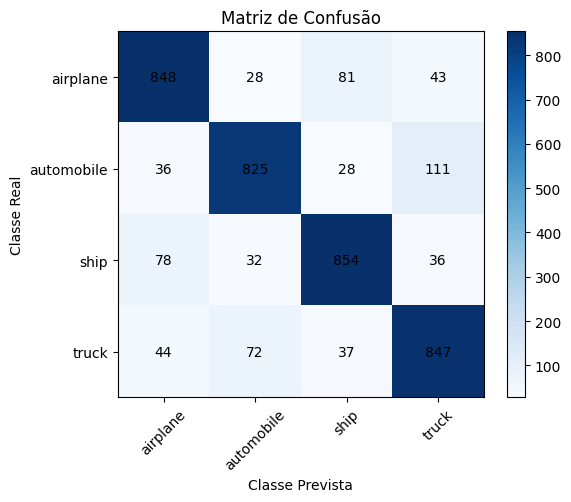

In [9]:
# Previsões para todo o conjunto de teste
y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Matriz de confusão
matriz_confusao = tf.math.confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

# Exibição
plt.figure(figsize=(6, 5))

plt.imshow(matriz_confusao, cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")

plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

plt.colorbar()

# Valores dentro da matriz
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(
            j, i,
            matriz_confusao[i, j].numpy(),
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

## **7. Inferência com uma imagem do teste**

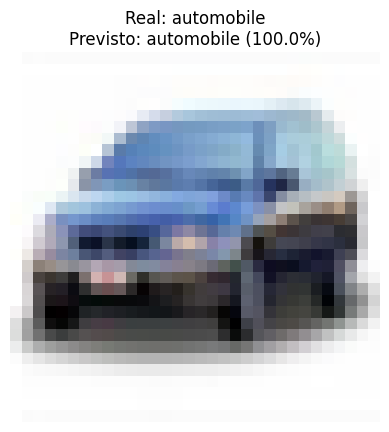

In [10]:
# Escolher uma imagem, alterando apenas o índice
indice = 122

imagem = x_test[indice]
classe_real = y_test[indice][0]

# Preparar para o modelo
imagem_modelo = np.expand_dims(imagem, axis=0)

# Fazer a previsão
previsoes = model.predict(imagem_modelo, verbose=0)

classe_prevista = np.argmax(previsoes)
confianca = np.max(previsoes)

# Mostrar resultado
plt.imshow(imagem)
plt.title(
    f"Real: {class_names[classe_real]}\n"
    f"Previsto: {class_names[classe_prevista]} ({confianca:.1%})"
)
plt.axis("off")
plt.show()


## **8. Inferência com uma imagem externa**

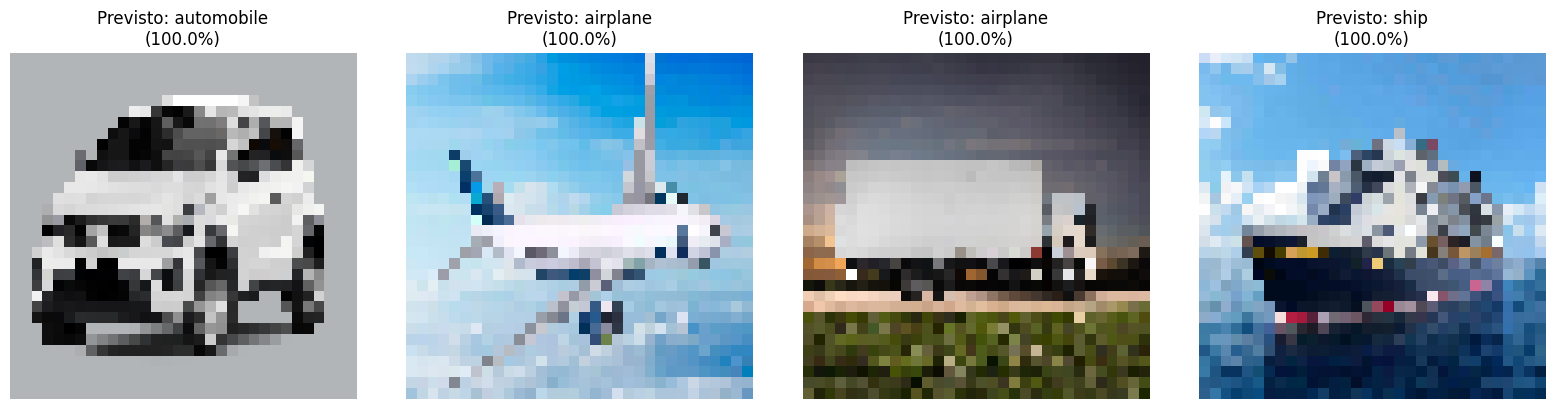

In [11]:
# Lista com os nomes dos arquivos de imagem (coloque quantos quiser)
NOMES_IMAGENS = [
    "/content/carro1.png",
    "/content/aviao.jpg",
    "/content/caminhao.jpg",
    "/content/barco.jpg"
]

plt.figure(figsize=(4 * len(NOMES_IMAGENS), 4))

for i, caminho in enumerate(NOMES_IMAGENS):
    img = tf.keras.utils.load_img(caminho, target_size=(32, 32))

    img_array = tf.keras.utils.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    previsoes = model.predict(img_array, verbose=0)

    classe_prevista = np.argmax(previsoes)
    confianca = np.max(previsoes)

    plt.subplot(1, len(NOMES_IMAGENS), i + 1)
    plt.imshow(img)
    plt.title(
        f"Previsto: {class_names[classe_prevista]}\n"
        f"({confianca:.1%})"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## **9. Vídeo — Modo A: câmera fixa, com rastreamento e contagem**

Para câmera **parada**, além de detectar os veículos (subtração de fundo, como antes), agora também **rastreamos** cada objeto entre frames e **contamos** quando ele cruza uma linha virtual — assim, cada carro/caminhão é contado uma única vez, mesmo aparecendo em dezenas de frames enquanto atravessa a tela.

**Como funciona:**
1. A subtração de fundo acha os blobs em movimento, como antes.
2. Um **rastreador por centróide** liga cada blob do frame atual ao objeto mais próximo do frame anterior, dando um ID que persiste enquanto o objeto está visível.
3. Cada objeto guarda os "votos" de classe que o modelo deu enquanto ele estava na tela — a classe final usada é a mais votada (isso deixa o rótulo mais estável do que classificar frame a frame).
4. Quando o **centro** do objeto cruza a linha vermelha desenhada no vídeo, ele é contado uma vez na classe mais votada e marcado como "já contado" (a caixa muda de verde pra vermelho).
5. Um placar no topo do vídeo acumula o total por classe.

In [12]:
from collections import Counter


class RastreadorCentroide:
    """Liga detecções de frames consecutivos pela distância entre centros, dando um ID estável a cada objeto."""

    def __init__(self, distancia_maxima=60, frames_para_esquecer=15):
        self.proximo_id = 0
        self.objetos = {}  # id -> {centro, caixa, votos, contado, sumido_ha, lado_anterior}
        self.distancia_maxima = distancia_maxima
        self.frames_para_esquecer = frames_para_esquecer

    def atualizar(self, deteccoes):
        ids_usados = set()

        for deteccao in deteccoes:
            melhor_id = None
            melhor_dist = self.distancia_maxima

            for obj_id, obj in self.objetos.items():
                if obj_id in ids_usados:
                    continue
                dist = np.hypot(
                    deteccao["centro"][0] - obj["centro"][0],
                    deteccao["centro"][1] - obj["centro"][1],
                )
                if dist < melhor_dist:
                    melhor_dist = dist
                    melhor_id = obj_id

            if melhor_id is not None:
                obj = self.objetos[melhor_id]
                obj["centro"] = deteccao["centro"]
                obj["caixa"] = deteccao["caixa"]
                obj["votos"][deteccao["classe"]] += 1
                obj["sumido_ha"] = 0
                ids_usados.add(melhor_id)
                deteccao["id"] = melhor_id
            else:
                novo_id = self.proximo_id
                self.proximo_id += 1
                self.objetos[novo_id] = {
                    "centro": deteccao["centro"],
                    "caixa": deteccao["caixa"],
                    "votos": Counter({deteccao["classe"]: 1}),
                    "contado": False,
                    "sumido_ha": 0,
                    "lado_anterior": None,
                }
                ids_usados.add(novo_id)
                deteccao["id"] = novo_id

        # Objetos não vistos nesse frame: aumenta o contador de sumiço, esquece se passar do limite
        for obj_id in list(self.objetos.keys()):
            if obj_id not in ids_usados:
                self.objetos[obj_id]["sumido_ha"] += 1
                if self.objetos[obj_id]["sumido_ha"] > self.frames_para_esquecer:
                    del self.objetos[obj_id]

        return deteccoes

In [15]:
from collections import Counter

CAMINHO_VIDEO = "/content/video_transito_carros.mp4"
CAMINHO_SAIDA = "/content/video_camera_fixa_contagem.mp4"
AREA_MINIMA = 500       # em pixels² — ignora ruído pequeno da subtração de fundo
POSICAO_LINHA = 0.7     # fração da LARGURA do vídeo onde fica a linha de contagem (vertical)
DISTANCIA_DUPLICATA = 80
FRAMES_RESFRIAMENTO = 45
MARGEM_UNIAO = 30       # px — caixas próximas/sobrepostas candidatas a fusão
AREA_FRAGMENTO = 4000   # px² — só funde se AO MENOS uma das caixas for menor que isso (ex: roda), nunca duas caixas grandes (2 carros)

# Decisão: todo veículo que cruza a linha conta como "automóvel" no placar,
# independente do que o CNN classificar (automobile/truck/etc). O modelo confunde
# SUVs com truck, e isso causava subcontagem -- aqui a contagem não depende mais disso.


def unir_caixas_proximas(caixas, margem=MARGEM_UNIAO, area_fragmento=AREA_FRAGMENTO):
    """Funde caixas (x, y, w, h) próximas/sobrepostas, mas só quando pelo menos uma delas
    é pequena (fragmento, ex: roda) -- duas caixas já grandes (2 carros distintos) não se fundem."""
    caixas = [list(c) for c in caixas]
    mudou = True
    while mudou:
        mudou = False
        for i in range(len(caixas)):
            for j in range(i + 1, len(caixas)):
                x1, y1, w1, h1 = caixas[i]
                x2, y2, w2, h2 = caixas[j]
                separadas = (
                    x1 - margem > x2 + w2 or x2 - margem > x1 + w1 or
                    y1 - margem > y2 + h2 or y2 - margem > y1 + h1
                )
                eh_fragmento = min(w1 * h1, w2 * h2) < area_fragmento
                if not separadas and eh_fragmento:
                    nx, ny = min(x1, x2), min(y1, y2)
                    nx2 = max(x1 + w1, x2 + w2)
                    ny2 = max(y1 + h1, y2 + h2)
                    caixas[i] = [nx, ny, nx2 - nx, ny2 - ny]
                    del caixas[j]
                    mudou = True
                    break
            if mudou:
                break
    return [tuple(c) for c in caixas]


cap = cv2.VideoCapture(CAMINHO_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
x_linha = int(largura * POSICAO_LINHA)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
saida = cv2.VideoWriter(CAMINHO_SAIDA, fourcc, fps, (largura, altura))

subtrator_fundo = cv2.createBackgroundSubtractorMOG2(history=30, varThreshold=40, detectShadows=False)
nucleo_limpeza = np.ones((5, 5), np.uint8)
nucleo_uniao = np.ones((25, 25), np.uint8)
rastreador = RastreadorCentroide(distancia_maxima=100, frames_para_esquecer=20)

total_automoveis = 0
contagens_recentes = []
frame_idx = 0

while cap.isOpened():
    ok, frame = cap.read()
    if not ok:
        break

    mascara = subtrator_fundo.apply(frame)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, nucleo_limpeza)
    mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, nucleo_uniao)
    contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    caixas_brutas = [
        cv2.boundingRect(c) for c in contornos if cv2.contourArea(c) >= AREA_MINIMA
    ]
    caixas = unir_caixas_proximas(caixas_brutas)

    # Não classificamos mais por CNN aqui -- todo blob que sobrevive ao filtro de área
    # e à fusão de caixas é tratado como um veículo (automóvel), sem depender do modelo
    deteccoes = []
    for x, y, w, h in caixas:
        centro = (x + w // 2, y + h // 2)
        deteccoes.append({"centro": centro, "caixa": (x, y, w, h), "classe": 0})  # "classe" é só um placeholder p/ o RastreadorCentroide, não é mais usado

    deteccoes = rastreador.atualizar(deteccoes)

    cv2.line(frame, (x_linha, 0), (x_linha, altura), (0, 0, 255), 2)

    for deteccao in deteccoes:
        obj_id = deteccao["id"]
        obj = rastreador.objetos[obj_id]
        x, y, w, h = deteccao["caixa"]

        centro_x, centro_y = deteccao["centro"]
        lado_atual = "esquerda" if centro_x < x_linha else "direita"
        cruzou = obj["lado_anterior"] is not None and obj["lado_anterior"] != lado_atual and not obj["contado"]
        obj["lado_anterior"] = lado_atual

        if cruzou:
            obj["contado"] = True

            eh_duplicata = any(
                frame_idx - f_antigo < FRAMES_RESFRIAMENTO
                and np.hypot(centro_x - x_antigo, centro_y - y_antigo) < DISTANCIA_DUPLICATA
                for f_antigo, x_antigo, y_antigo in contagens_recentes
            )
            if not eh_duplicata:
                total_automoveis += 1
                contagens_recentes.append((frame_idx, centro_x, centro_y))

        cor = (255, 0, 0) if obj["contado"] else (0, 255, 0)
        cv2.rectangle(frame, (x, y), (x + w, y + h), cor, 2)
        cv2.putText(
            frame, f"ID {obj_id}: automovel",
            (x, max(y - 10, 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, cor, 2
        )

    contagens_recentes = [c for c in contagens_recentes if frame_idx - c[0] < FRAMES_RESFRIAMENTO]

    cv2.rectangle(frame, (0, 0), (largura, 40), (0, 0, 0), -1)
    cv2.putText(frame, f"Automoveis contados: {total_automoveis}", (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    saida.write(frame)
    frame_idx += 1

cap.release()
saida.release()

print("Vídeo salvo em:", CAMINHO_SAIDA)
print("Total de automóveis contados:", total_automoveis)

Vídeo salvo em: /content/video_camera_fixa_contagem.mp4
Total de automóveis contados: 5


## 10 Vídeo aeroporto✈️

In [26]:
CAMINHO_VIDEO = "/content/aeroporto_reduzido.mp4"
CAMINHO_SAIDA = "/content/aeroporto_com_deteccoes.mp4"
IMG_SIZE = 32
CORES = {"airplane": (0, 255, 255), "truck": (0, 140, 255), "automobile": (0, 255, 0)}

# Calibrado visualmente neste video especifico (fixo, nao se move o clipe todo)
CAIXA_AVIAO_FIXA = (450, 95, 190, 80)  # x, y, w, h

# Calibrado visualmente: o carro se move em linha quase reta da esquerda pra direita
CARRO_FRAME_INICIAL = 285
CARRO_X_INICIAL = 200
CARRO_VELOCIDADE_PX = 3.7   # pixels por frame
CARRO_Y = 175
CARRO_LARGURA = 48
CARRO_ALTURA = 25

# Caminhao: continua por deteccao de movimento normal (ja esta funcionando bem)
AREA_MINIMA = 800
INDICE_TRUCK = class_names.index("truck")

cap = cv2.VideoCapture(CAMINHO_VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS)
largura = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
altura = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
saida = cv2.VideoWriter(CAMINHO_SAIDA, fourcc, fps, (largura, altura))
if not saida.isOpened():
    raise RuntimeError("VideoWriter nao abriu -- confira o caminho/codec.")

subtrator_fundo = cv2.createBackgroundSubtractorMOG2(history=120, varThreshold=25, detectShadows=False)
nucleo_limpeza = np.ones((5, 5), np.uint8)
nucleo_juntar = np.ones((9, 9), np.uint8)
rastreador = RastreadorCentroide(distancia_maxima=60, frames_para_esquecer=25)

frame_idx = 0

try:
    while cap.isOpened():
        ok, frame = cap.read()
        if not ok:
            break
        frame_idx = frame_idx + 1

        # --- Caminhao por deteccao de movimento ---
        mascara = subtrator_fundo.apply(frame)
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_OPEN, nucleo_limpeza)
        mascara = cv2.morphologyEx(mascara, cv2.MORPH_CLOSE, nucleo_juntar)
        contornos, _ = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        deteccoes = []
        for contorno in contornos:
            if cv2.contourArea(contorno) < AREA_MINIMA:
                continue
            x, y, w, h = cv2.boundingRect(contorno)
            recorte = frame[y:y + h, x:x + w]
            if recorte.size == 0:
                continue
            recorte_rgb = cv2.cvtColor(recorte, cv2.COLOR_BGR2RGB)
            recorte_redimensionado = cv2.resize(recorte_rgb, (IMG_SIZE, IMG_SIZE))
            entrada = np.expand_dims(recorte_redimensionado / 255.0, axis=0)
            previsoes = model.predict(entrada, verbose=0)[0]
            if previsoes[INDICE_TRUCK] < 0.4:
                continue
            centro = (x + w // 2, y + h // 2)
            deteccoes.append({"centro": centro, "caixa": (x, y, w, h), "classe": INDICE_TRUCK})

        deteccoes = rastreador.atualizar(deteccoes)
        for deteccao in deteccoes:
            x, y, w, h = deteccao["caixa"]
            cv2.rectangle(frame, (x, y), (x + w, y + h), CORES["truck"], 2)
            cv2.putText(frame, "truck", (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, CORES["truck"], 2)

        # --- Aviao: caixa fixa ---
        xa, ya, wa, ha = CAIXA_AVIAO_FIXA
        cv2.rectangle(frame, (xa, ya), (xa + wa, ya + ha), CORES["airplane"], 2)
        cv2.putText(frame, "airplane", (xa, max(ya - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, CORES["airplane"], 2)

        # --- Carro: posicao calculada pela formula linear ---
        if frame_idx >= CARRO_FRAME_INICIAL:
            xc = int(CARRO_X_INICIAL + (frame_idx - CARRO_FRAME_INICIAL) * CARRO_VELOCIDADE_PX)
            if 0 <= xc <= largura - CARRO_LARGURA:
                cv2.rectangle(frame, (xc, CARRO_Y), (xc + CARRO_LARGURA, CARRO_Y + CARRO_ALTURA), CORES["automobile"], 2)
                cv2.putText(frame, "automobile", (xc, max(CARRO_Y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, CORES["automobile"], 2)

        saida.write(frame)

finally:
    cap.release()
    saida.release()

print("Video salvo em:", CAMINHO_SAIDA)
print("Total de frames processados:", frame_idx)

Video salvo em: /content/aeroporto_com_deteccoes.mp4
Total de frames processados: 541
